# OR and XOR Separators

Course: Introduction to Deep Learning

This notebook is a structured template for studying linear separability with the Boolean `OR` and `XOR` functions.

Goals:
- visualize the four Boolean input combinations,
- find a linear separator for `OR`,
- explain why `XOR` is not linearly separable,
- sketch how a small multilayer perceptron can represent `XOR`.


## Task 1: Define the Boolean Datasets

We use the four binary input pairs:
- `(0, 0)`
- `(0, 1)`
- `(1, 0)`
- `(1, 1)`

**TODO:** Verify the label vectors for `OR` and `XOR`.

**TODO:** Write down the truth table in your own words before continuing.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
])

y_or = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

print("Inputs:\n", X)
print("OR labels: ", y_or)
print("XOR labels:", y_xor)


Inputs:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
OR labels:  [0 1 1 1]
XOR labels: [0 1 1 0]


## Task 2: Visualize OR and XOR

A separator is easiest to understand once the points are plotted in 2D.

**TODO:** Inspect the plots and describe which class labels are grouped together for `OR`.

**TODO:** Inspect the `XOR` plot and explain why the positive class is arranged differently.


In [3]:
def plot_points(ax, X, y, title):
    colors = np.where(y == 1, "tab:blue", "tab:orange")
    markers = np.where(y == 1, "o", "s")

    for point, label, color, marker in zip(X, y, colors, markers):
        ax.scatter(point[0], point[1], c=color, marker=marker, s=140, edgecolor="black")
        ax.text(point[0] + 0.03, point[1] + 0.03, f"{tuple(point.astype(int))} -> {label}")

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    ax.grid(alpha=0.3)


def plot_separator(ax, w, b, label="separator"):
    if np.allclose(w, 0):
        return

    xs = np.linspace(-0.5, 1.5, 200)

    if abs(w[1]) > 1e-12:
        ys = -(w[0] * xs + b) / w[1]
        ax.plot(xs, ys, linewidth=2, label=label)
    elif abs(w[0]) > 1e-12:
        ax.axvline(-b / w[0], linewidth=2, label=label)


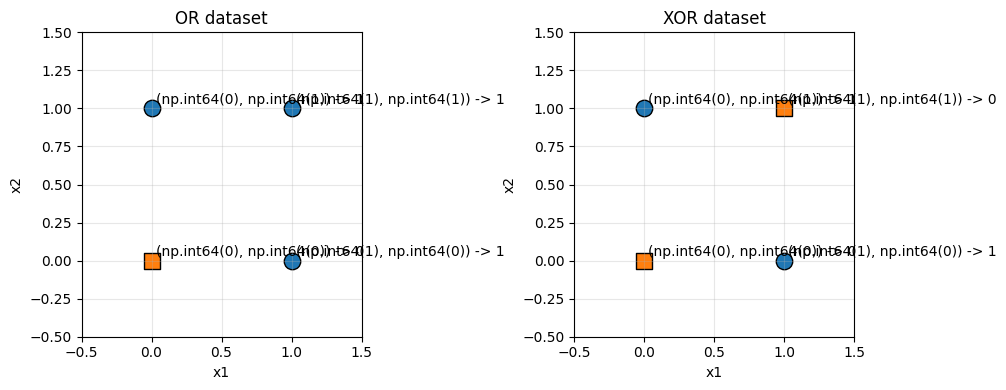

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_points(axes[0], X, y_or, "OR dataset")
plot_points(axes[1], X, y_xor, "XOR dataset")

plt.tight_layout()
plt.show()


## Task 3: OR with a Single Linear Separator

A perceptron with weights `w` and bias `b` makes a decision using

$$z = w_1 x_1 + w_2 x_2 + b$$
$$\hat{y} = \mathrm{step}(z)$$

The line `w_1 x_1 + w_2 x_2 + b = 0` is the decision boundary.

**TODO:** Choose weights and a bias that classify the `OR` labels correctly.

**TODO:** Compute the logits `z` for all four inputs.

**TODO:** Plot your separator and explain which side of the line corresponds to class `1`.


OR logits:      [-0.25  0.75  0.75  1.75]
OR predictions: [0 1 1 1]
Correct:        True


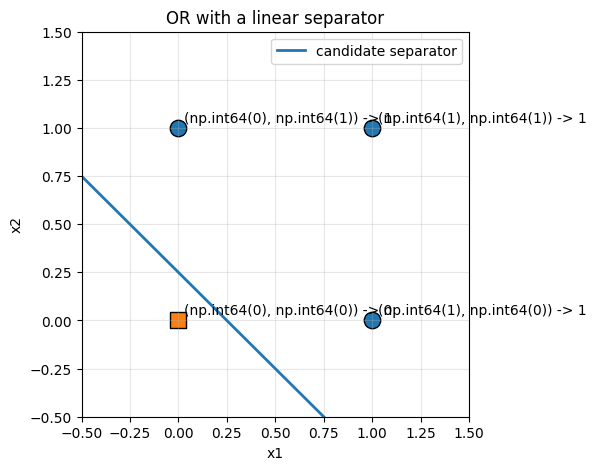

In [9]:
def step(z):
    return (z >= 0).astype(int)


# TODO: Replace these placeholders with a correct separator for OR.
w_or = np.array([1.0, 1.0])
b_or = -0.25

logits_or = X @ w_or + b_or
pred_or = step(logits_or)

print("OR logits:     ", logits_or)
print("OR predictions:", pred_or)
print("Correct:       ", np.array_equal(pred_or, y_or))

# TODO: Once you found a valid separator, visualize it below.
fig, ax = plt.subplots(figsize=(5, 5))
plot_points(ax, X, y_or, "OR with a linear separator")
plot_separator(ax, w_or, b_or, label="candidate separator")
ax.legend()
plt.show()


## Task 4: Why XOR Cannot Be Solved by One Line

For `XOR`, the positive points are `(0, 1)` and `(1, 0)`, while the negative points are `(0, 0)` and `(1, 1)`.

**TODO:** Argue geometrically why no single straight line can separate these two classes.

**TODO:** Try a few candidate lines and confirm that at least one point is always misclassified.

**TODO:** Summarize in one sentence what this tells us about the limitations of a single-layer perceptron.


In [6]:
# TODO: Add your own candidate separators here and inspect the predictions.
candidates = [
    (np.array([1.0, 1.0]), -0.5),
    (np.array([1.0, -1.0]), 0.0),
    (np.array([-1.0, 1.0]), 0.0),
]

for i, (w, b) in enumerate(candidates, start=1):
    pred = step(X @ w + b)
    print(f"Candidate {i}: w={w}, b={b}, pred={pred}, correct={np.array_equal(pred, y_xor)}")


Candidate 1: w=[1. 1.], b=-0.5, pred=[0 1 1 1], correct=False
Candidate 2: w=[ 1. -1.], b=0.0, pred=[1 0 1 1], correct=False
Candidate 3: w=[-1.  1.], b=0.0, pred=[1 1 0 1], correct=False


## Task 5: XOR with a Hidden Layer

A multilayer perceptron can combine multiple linear separators.

One useful perspective is:
- hidden neuron 1 detects one half-space,
- hidden neuron 2 detects another half-space,
- the output neuron combines both hidden activations.

**TODO:** Design a two-layer network that computes `XOR`.

**TODO:** State the shapes of `W1`, `b1`, `W2`, and `b2` for a network with 2 inputs, 2 hidden neurons, and 1 output.

**TODO:** Explain how each hidden neuron contributes to the final `XOR` decision.


In [13]:
def forward_two_layer(X, W1, b1, W2, b2):
    hidden = step(X @ W1.T + b1)
    output = step(hidden @ W2 + b2)
    return hidden, output


# TODO: Replace the placeholders below with parameters that implement XOR.
W1 = np.array([
    [1.0, 1.0],
    [1.0, 1.0],
])
b1 = np.array([-0.25, -1.25])
W2 = np.array([1.0, -1.0])
b2 = -0.1
hidden_xor, pred_xor = forward_two_layer(X, W1, b1, W2, b2)

print("Hidden activations:\n", hidden_xor)
print("XOR predictions:   ", pred_xor)
print("Correct:           ", np.array_equal(pred_xor, y_xor))


Hidden activations:
 [[0 0]
 [1 0]
 [1 0]
 [1 1]]
XOR predictions:    [0 1 1 0]
Correct:            True


## Reflection

**TODO:** Explain in 2-3 sentences why `OR` is linearly separable but `XOR` is not.

**TODO:** State what extra representational power the hidden layer adds.

**TODO:** If you changed the activation from a step function to sigmoid, what would stay conceptually the same and what would change in training?
